# [LAB-09] 선형회귀ㅣ1-단순선형회귀(실습코드)

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import *

# 선형회귀를 위한 참조 
# -> 선형회귀 구현 방식이 두가지 이므로 두 종류의 참조를 모두 가져온다. 
from statsmodels.api import add_constant, OLS
from statsmodels.formula.api import ols as formula_ols

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 

In [2]:
origin = load_data('cars')
display(origin.head()) # 상위 5건 출력
display(origin.tail()) # 하위 5건 출력 

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


,speed,dist
45,24,70
46,24,92
47,24,93
48,24,120
49,25,85


## #02. 탐색적 데이터 분석 

### 1. 종속변수와 독립변수간의 상관분석 


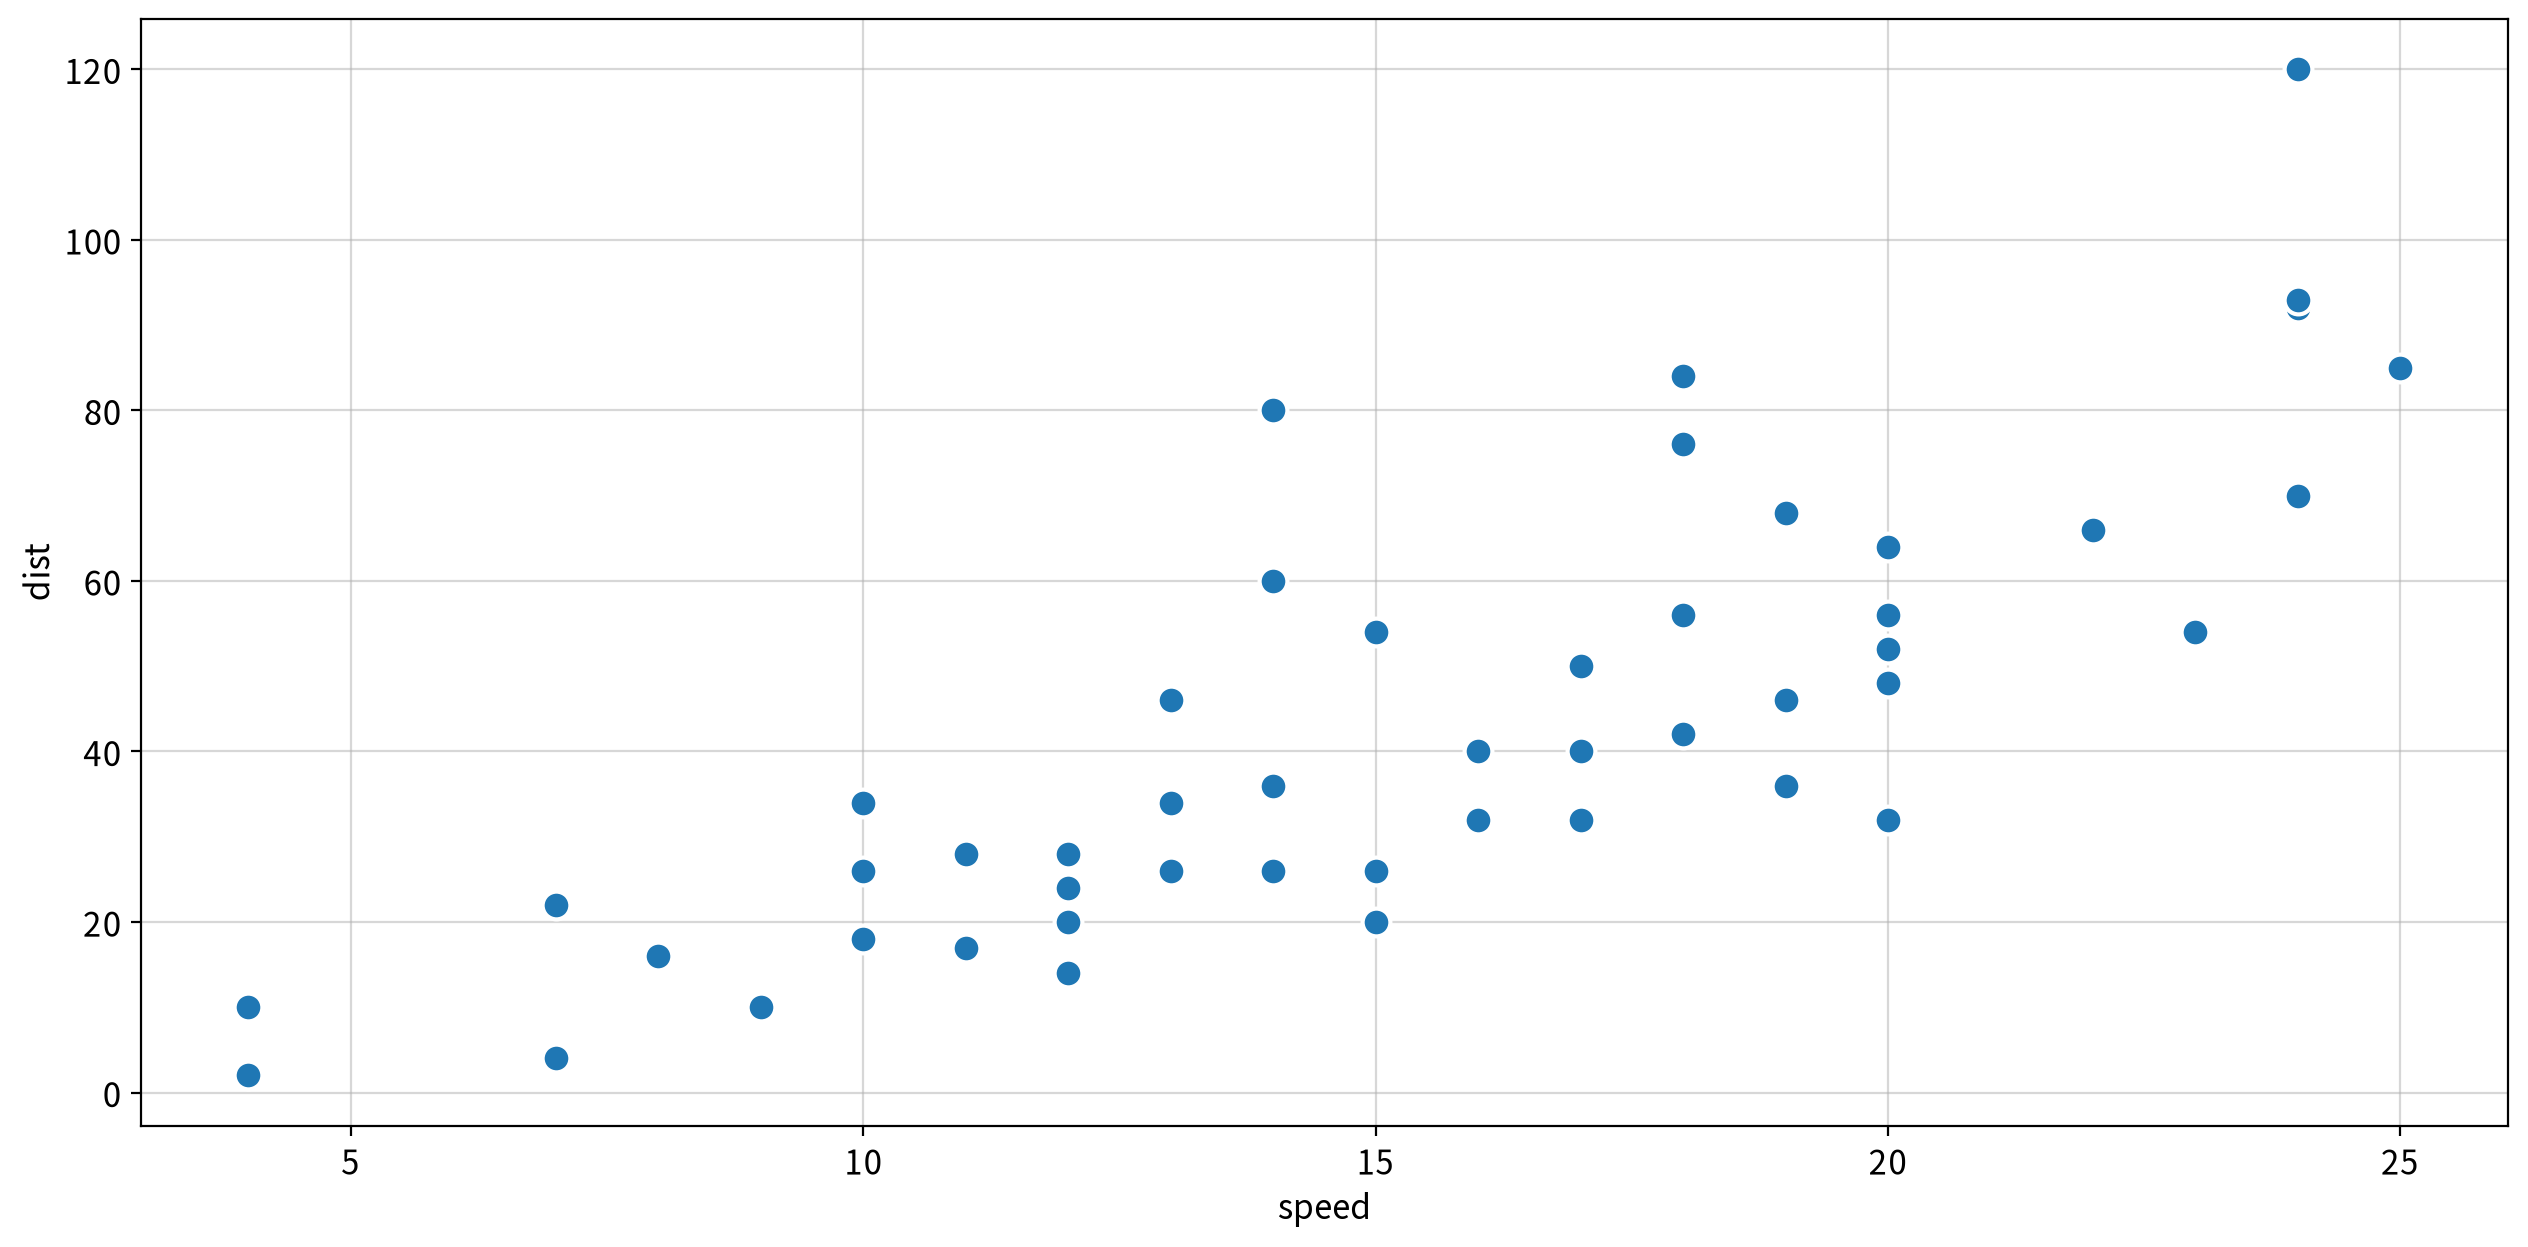

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
speed,dist,Pearson,0.807,0.000,Strong,True,True,True,False,False


In [3]:
my_stats.correlation(origin, 'speed', 'dist', plot=True)

## #03. 행렬기반 방식의 단순선형회귀 

### 1. 독립변수 행렬 준비 

In [4]:
x = origin[["speed"]]
x.head()

,speed
0,4
1,4
2,7
3,7
4,8


### 2. 종속변수 준비 

In [5]:
y = origin["dist"]
y.head()

0     2
1    10
2     4
3    22
4    16
Name: dist, dtype: int64

### 3. 상수항 추가 

In [6]:
x_input = add_constant(x) # cost라는 이름의 상수항 추가 
x_input.head()            # 상위 5건 확인

,const,speed
0,1.000,4
1,1.000,4
2,1.000,7
3,1.000,7
4,1.000,8


### 4. 회귀분석 수행 

In [7]:
# OLS 모델 객체 생성 
# -> 이 단계에서는 아직 학습(fit)되지 않은 '모형의 틀'만 만들어짐
model = OLS(y, x_input)

# 모델 적합(Fit)
# -> 데이터를 이용해 회귀계수(베타)를 추정하고, 모델을 완성하는 단계
fit = model.fit()

# 적합된 모델 객체의 분석 결과 확인 
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        18:05:36   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

## #04. formula API 방식의 선형회귀 

### 1. 단순선형회귀 구현 

In [8]:
# 학습 모델 객체 생성 
model = formula_ols("dist ~ speed", data=origin)

# 모델 적합 
fit = model.fit()

# 분석 결과 확인 
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        18:05:36   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

## #05. 실제 데이터와 모형의 예측값 비교 

### 1. 원본 데이터 + 가상 데이터(예측용)

In [9]:
df = origin.copy()

# 최고 속도 이후의 5단계 값을 가상으로 추가한다. 
for i in range(1, 6): # <-- i의 범위: 1~5
    # df의 인덱스는 0부터 len(df) - 1까지 존재하므로, 
    # len(df)위치에 대한 대입은 새로운 행을 추가하는 것과 동일하다.
    # -> speed 컬럼에는 최고속도 + i 값을 대입하고, 
    # dist 컬럼에는 None을 대입한다.
    df.loc[len(df)] = [df["speed"].max() + i, None]

# 하위 10건 확인 
# 마지막에 추가된 5건은 제동거리(dist) 값이 None으로 되어있다.
display(df.tail(10))

,speed,dist
45,24.000,70.000
46,24.000,92.000
47,24.000,93.000
48,24.000,120.000
49,25.000,85.000
50,26.000,NaN
51,28.000,NaN
52,31.000,NaN
53,35.000,NaN
54,40.000,NaN


### 2. 예측값 생성 

In [10]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다. 
predict_input = add_constant(df["speed"])

# 예측값을 생성하여 pred 컬럼으로 추가한다. 
df['pred'] = fit.predict(predict_input)

display(df.tail(10))    # 하위 10건 확인 

,speed,dist,pred
45,24.000,70.000,76.799
46,24.000,92.000,76.799
47,24.000,93.000,76.799
48,24.000,120.000,76.799
49,25.000,85.000,80.731
50,26.000,NaN,84.664
51,28.000,NaN,92.528
52,31.000,NaN,104.326
53,35.000,NaN,120.055
54,40.000,NaN,139.717


### 3. 시각화를 위해 long 타입으로 재배치 

In [11]:
df_melt = df.melt(
    id_vars="speed",                # speed는 그대로 둠 
    value_vars=["dist", "pred"],    # long 형태로 변환할 변수
    var_name="variable",            # 명목형 변수명   
    value_name="value"              # 값 변수명 
)

display(df_melt.head(10))
display(df_melt.tail(10))

,speed,variable,value
0,4.000,dist,2.000
1,4.000,dist,10.000
2,7.000,dist,4.000
3,7.000,dist,22.000
4,8.000,dist,16.000
5,9.000,dist,10.000
6,10.000,dist,18.000
7,10.000,dist,26.000
8,10.000,dist,34.000
9,11.000,dist,17.000


,speed,variable,value
100,24.000,pred,76.799
101,24.000,pred,76.799
102,24.000,pred,76.799
103,24.000,pred,76.799
104,25.000,pred,80.731
105,26.000,pred,84.664
106,28.000,pred,92.528
107,31.000,pred,104.326
108,35.000,pred,120.055
109,40.000,pred,139.717


### 4. 시각화 비교 

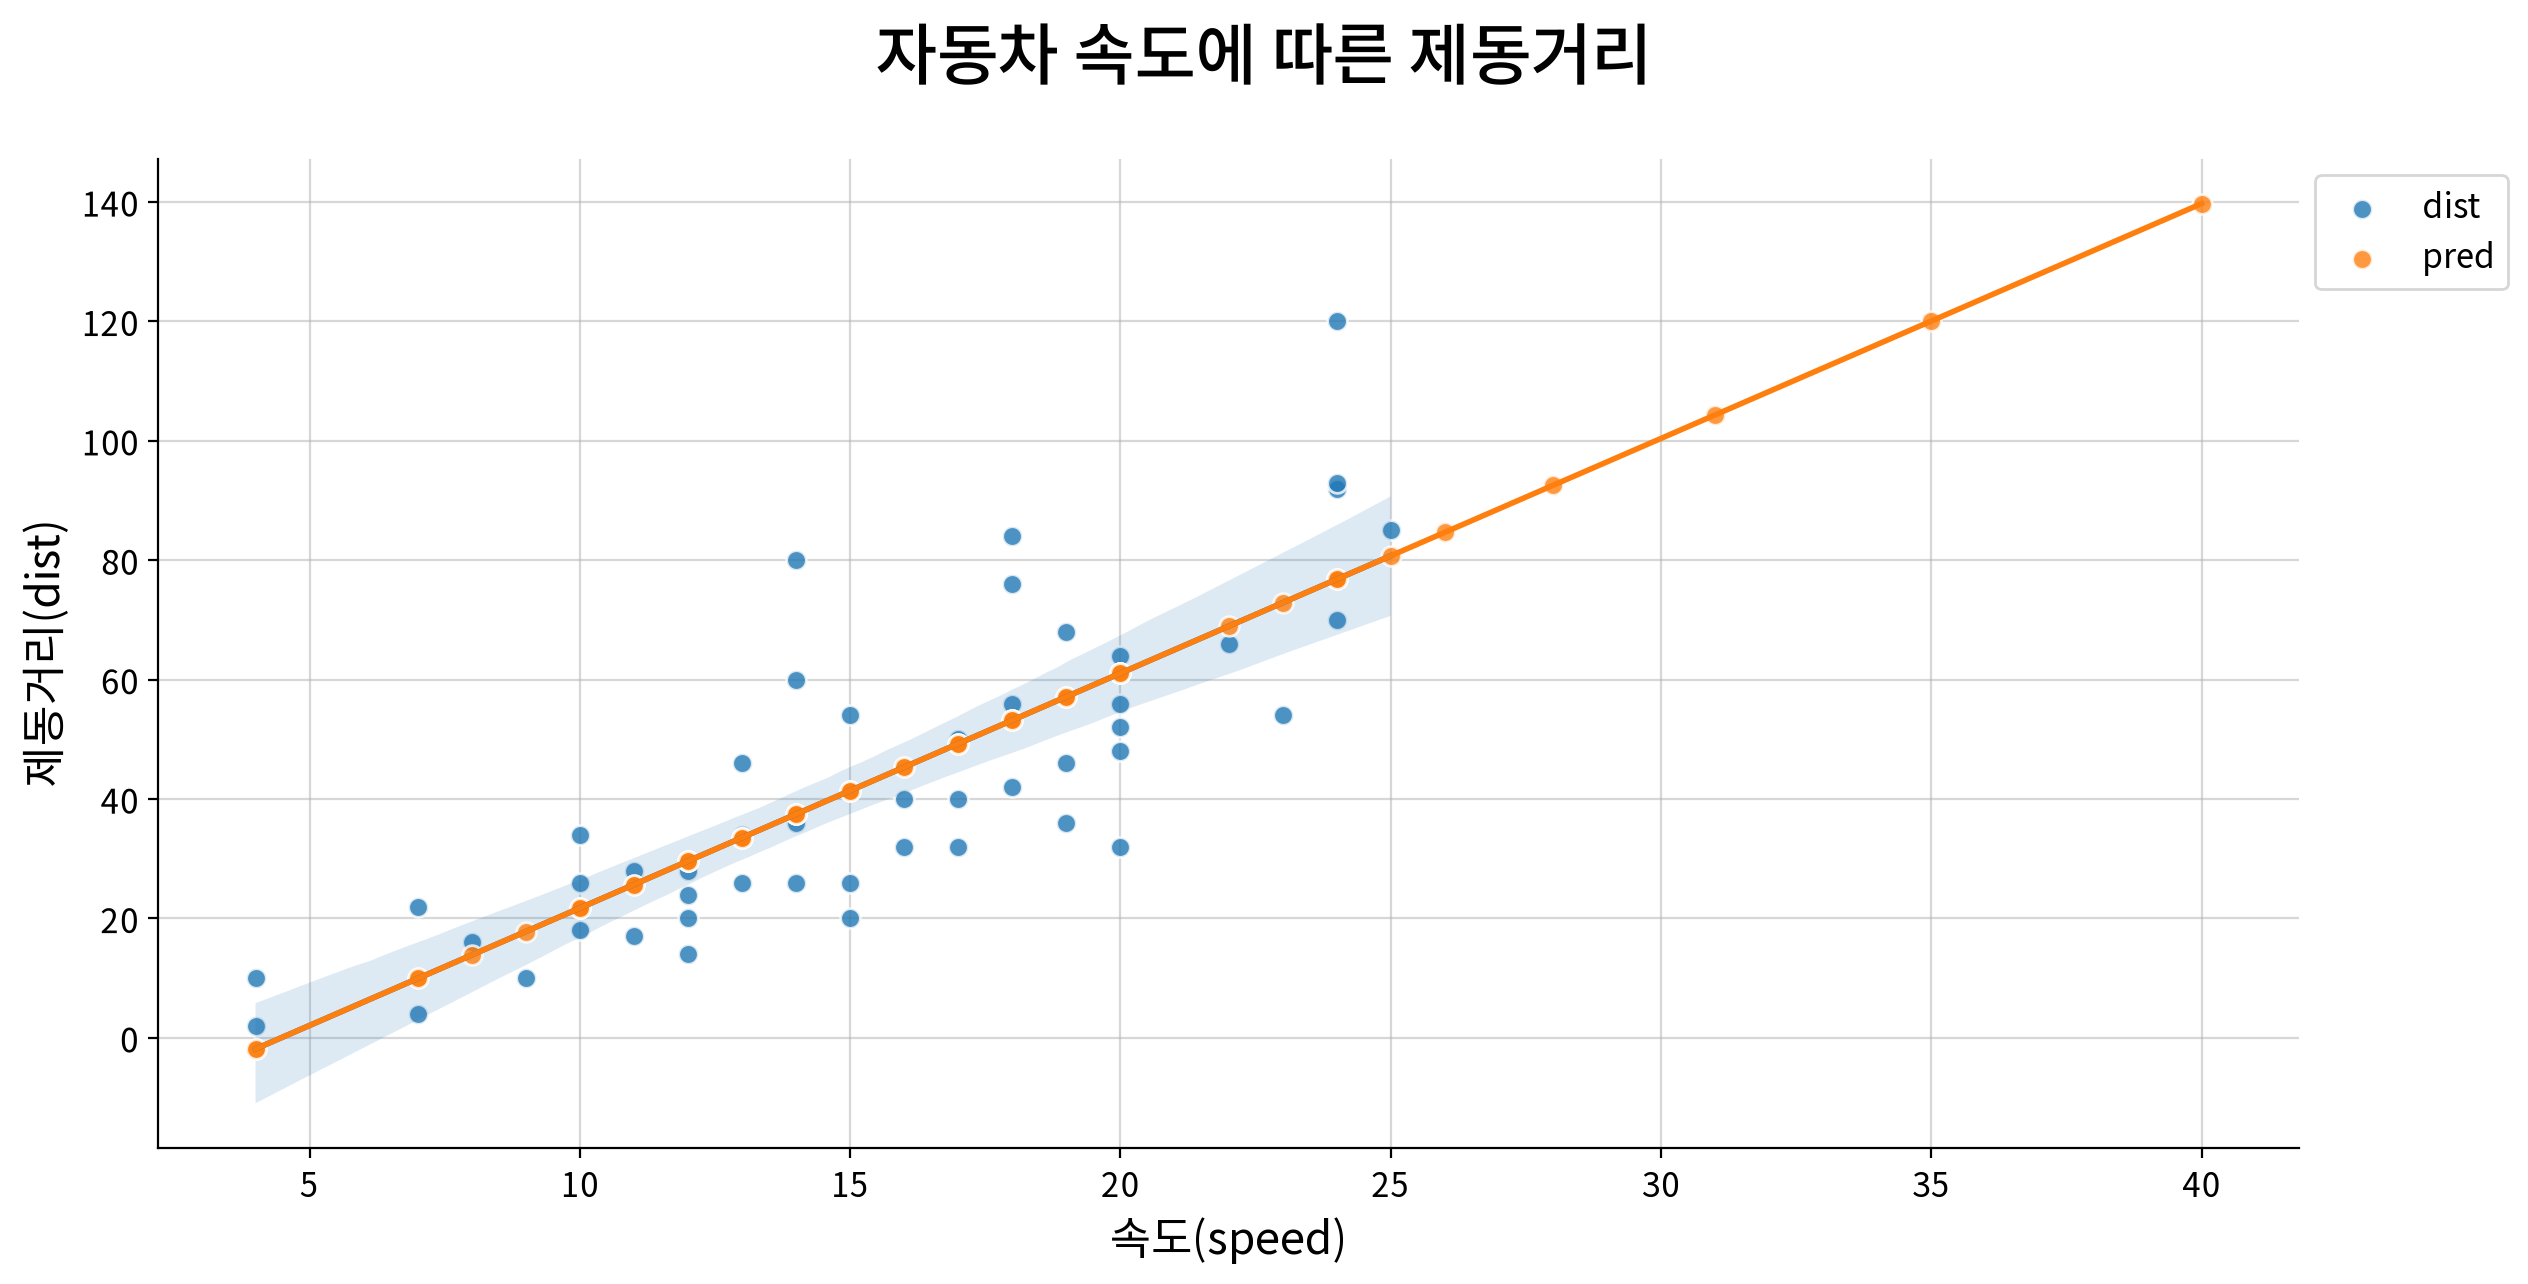

In [12]:
my_plot.lmplot(df_melt, x="speed", y="value",
               hue="variable", title='자동차 속도에 따른 제동거리', 
               xlabel='속도(speed)', ylabel='제동거리(dist)')

## #05. 모듈화 기능 확인 

### 1. 모델 적합 

In [13]:
fit = my_ols.fit_model(origin, y='dist', summary=True)

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        18:05:36   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

### 2. 예측값 생성 

In [14]:
pred = my_ols.predict(fit, origin[['speed']])

new_df = origin.copy()
new_df['pred'] = pred
new_df.head()

,speed,dist,pred
0,4,2,-1.849
1,4,10,-1.849
2,7,4,9.948
3,7,22,9.948
4,8,16,13.880


## #연습문제 01 

준비작업 

라이브러리 참조 

In [15]:
from jussam import load_data
from helpers import *
from pandas import DataFrame, concat

데이터 가져오기 

In [16]:
df = load_data("father-son")
df.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


## 문제 풀이

### Mission 1. 데이터와 친해지기 (EDA)

father-son 데이터를 불러와 크기·자료형·기초통계량을 확인하라.

산점도(scatter plot)를 그려 아버지 키(fheight)와 아들 키(sheight) 사이에 어떤 경향이 보이는지 눈으로 관찰하라.

두 변수의 상관계수를 구하고, 회귀분석을 적용해도 되는지 근거를 대라.

#### 크기, 자료형, 기초통계량

In [17]:
print(df.shape)

(1078, 2)


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB


In [19]:
my_qtcheck.numerical_summary(df).T

,fheight,sheight
count,1078.000,1078.000
mean,67.687,68.684
std,2.745,2.815
min,59.008,58.507
25%,65.788,66.931
50%,67.767,68.616
75%,69.603,70.466
max,75.434,78.365
rel_diff,0.001,0.001
rdiff_flag,similar,similar


#### 산점도 + 상관분석

`my_stats.correlation()` 은 정규성·선형성·영향점 가정을 자동 점검해 **Pearson / Spearman** 을 선택하고,
상관계수·유의확률·강도를 한 번에 산출하며 산점도를 함께 그려준다.

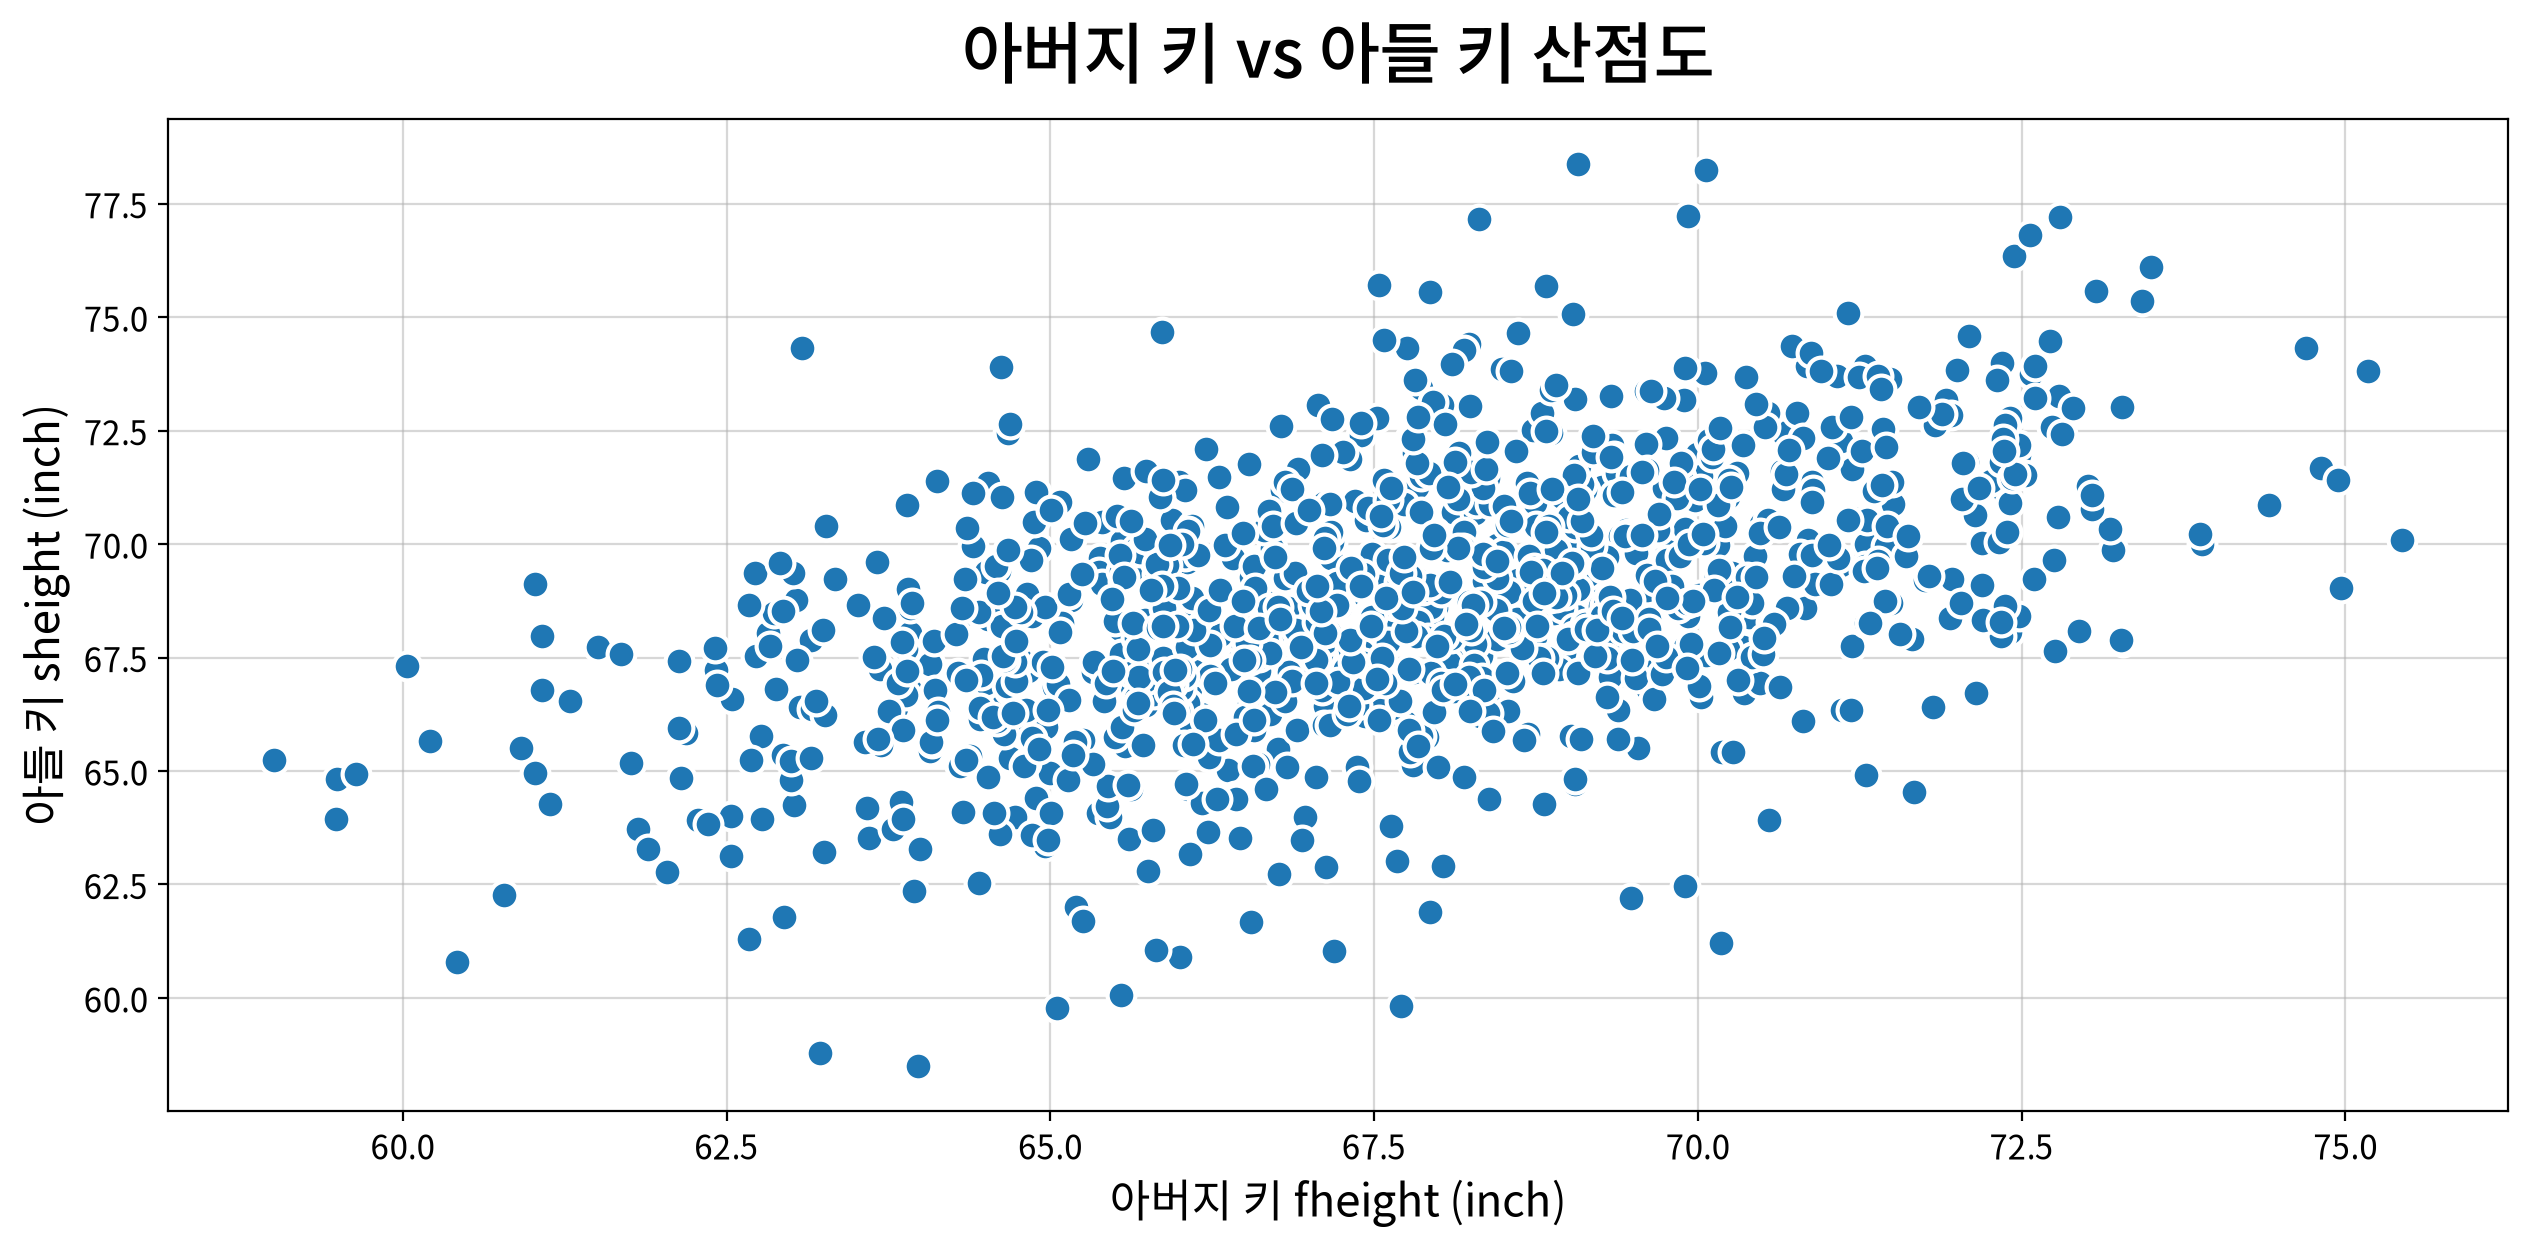

x,fheight
y,sheight
method,Spearman
coef,0.506
p-value,0.000
strength,Moderate
normality_x,True
normality_y,False
linearity,True
influential_outlier,False
high_skew,False


In [20]:
# -- 상관분석(가정 점검 포함) + 산점도 --
corr = my_stats.correlation(
    df, x='fheight', y='sheight', 
    title='아버지 키 vs 아들 키 산점도', 
    xlabel='아버지 키 fheight (inch)', ylabel='아들 키 sheight (inch)'  
)
corr.T

#### 🔎 관찰 및 회귀분석 가능 여부 판단

- **경향** : 산점도를 보면 아버지 키(fheight)가 클수록 아들 키(sheight)도 커지는 **우상향(양의) 선형 경향**이 보인다.
- **상관계수** : 위 표의 `coef` — 약 0.5 수준의 **양의 중간(Moderate) 상관**이며 `significant=True`(p<0.05)로 통계적으로 유의하다.
- **선형성** : `linearity=True` — Ramsey RESET 검정에서 계결림이 남지 않아 직선 관계로 설명 가능하다.

→ 두 변수는 **유의한 양의 선형 관계**를 가지므로, 아버지 키로 아들 키를 설명하는 **단순선형회귀 적용이 타당**하다.

### Mission 2. 회귀식 유도하기

아들 키(`sheight`)를 **종속변수**, 아버지 키(`fheight`)를 **독립변수**로 하는 단순선형회귀 모형을 적합한

In [21]:
fit = my_ols.fit_model(df, y='sheight', summary=True)

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        18:05:37   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

#### 🔎 회귀식 유도

$sheight = 33.887 + 0.514 \times fheight$

### Mission 3. 미지의 5명, 그 아들들의 키를 예측하라

새 등록 신청자 5명의 아버지 키 `[73.5, 72.6, 68.3, 71.9, 74.1]` 을 원본 데이터와 병합한 새 데이터셋을 만들고, 앞서 유도한 회귀식으로 아들 키를 예측한다.

In [22]:
# -- 새 신청자 5명의 아버지 키 -- 
new_fheight = [73.5, 72.6, 68.3, 71.9, 74.1]
new_x = DataFrame({'fheight': new_fheight})
new_x

,fheight
0,73.500
1,72.600
2,68.300
3,71.900
4,74.100


In [23]:
# -- 회귀식으로 아들 키 예측 (my_ols.predict)
pred = my_ols.predict(fit, new_x)

# 예측된 아들 키를 sheight 컬럼으로 붙인 가상 데이터 5건 
new_df = new_x.copy()
new_df['sheight'] = pred['pred'].values
new_df.head()

,fheight,sheight
0,73.500,71.672
1,72.600,71.210
2,68.300,68.999
3,71.900,70.850
4,74.100,71.981


In [24]:
# -- 원본 1,078건 + 가상 5건 병합하여 새 데이터셋 구성 --
real_df = df.copy()
real_df['source'] = '실제 데이터'
new_df['source'] = '가상 데이터'

merged = concat([real_df, new_df], ignore_index=True)

print(f'병합 데이터셋 크기: {merged.shape[0]}행 (실제 {len(real_df)} + 가상{len(new_df)})')
print('병합 결과의 마지막 8행 (예측된 가상 5명 포함):')
merged.tail(8)

병합 데이터셋 크기: 1083행 (실제 1078 + 가상5)
병합 결과의 마지막 8행 (예측된 가상 5명 포함):


,fheight,sheight,source
1075,71.783,69.306,실제 데이터
1076,70.738,69.302,실제 데이터
1077,70.306,67.015,실제 데이터
1078,73.500,71.672,가상 데이터
1079,72.600,71.210,가상 데이터
1080,68.300,68.999,가상 데이터
1081,71.900,70.850,가상 데이터
1082,74.100,71.981,가상 데이터


### Mission 4. 한 장의 그래프로 보고하기

실제 데이터 1,078건과 예측한 가상 데이터 5건을 하나의 산점도에 함께 그리고,
색·모양으로 구분한다. 회귀 직선을 함께 그려 5명의 예측값이 직선 위에 정확히 놓임을 확인한다.

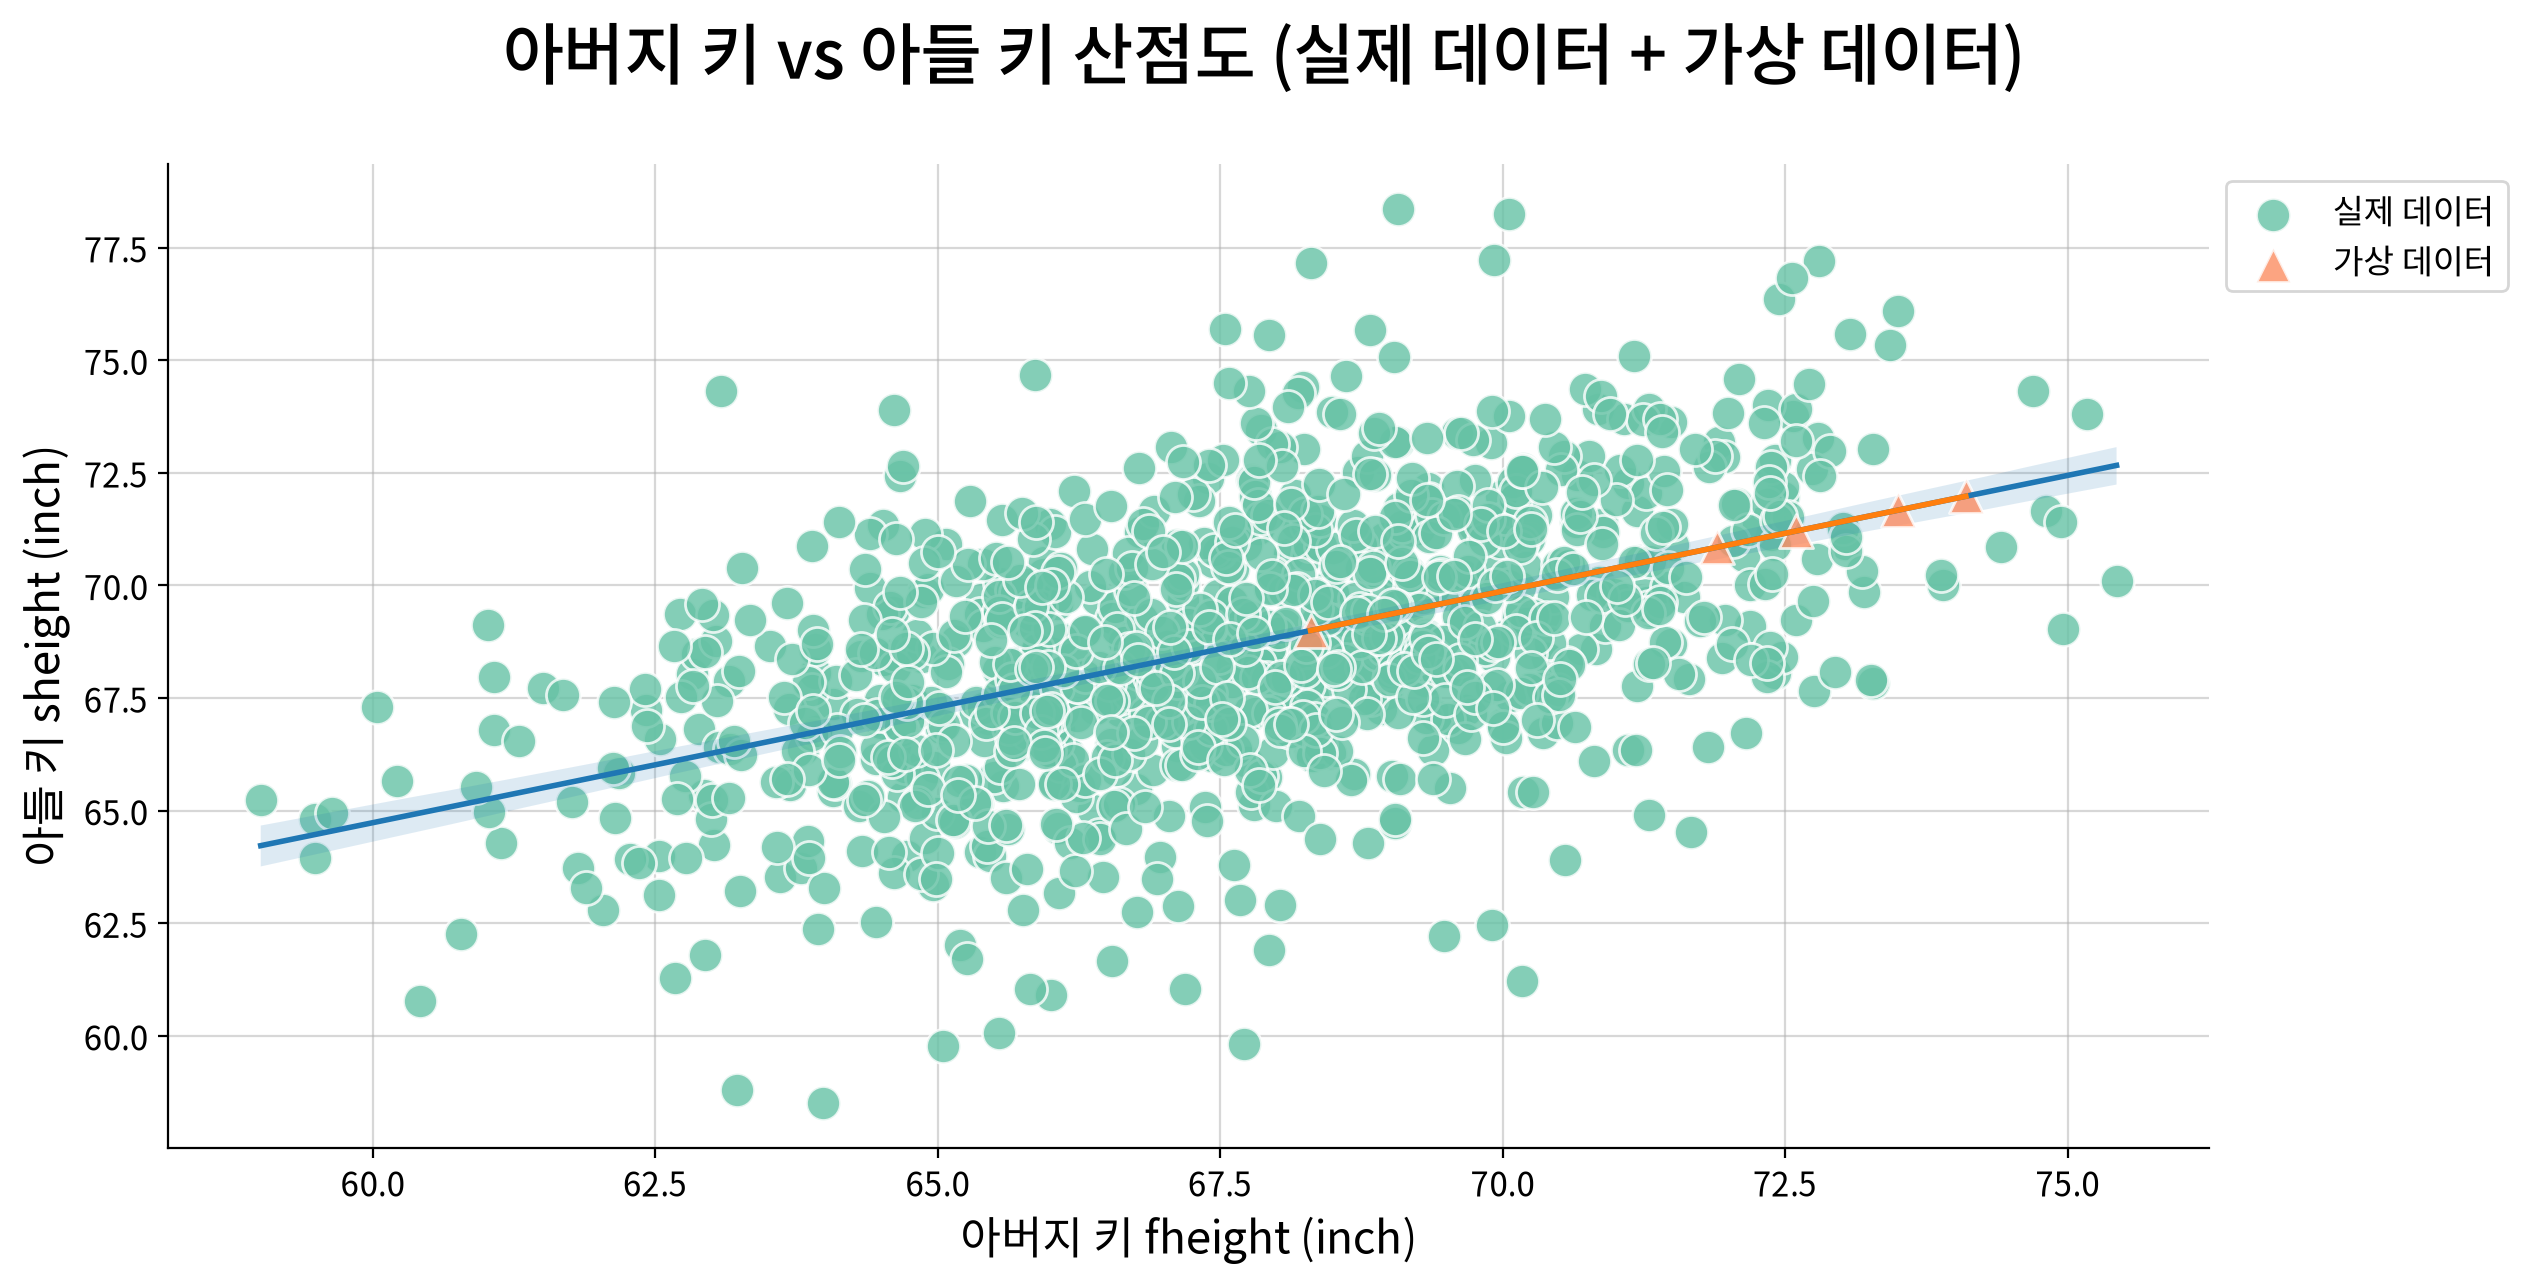

In [25]:
my_plot.lmplot(
    merged, x='fheight', y='sheight', hue='source', 
    markers=['o', '^'], palette='Set2', scatter_size=150,
    title='아버지 키 vs 아들 키 산점도 (실제 데이터 + 가상 데이터)', 
    xlabel='아버지 키 fheight (inch)', ylabel='아들 키 sheight (inch)'
)

### 📌 보고 요약

- 연두색 동그라미은 **실제 데이터 1,078명**, 주황색 삼각형은 **예측한 가상 5명**이다.
- 5개의 삼각형은 모두 **회귀 직선 위에 정확히** 놓여 있다 — 예측값이 회귀식 $\hat{sheight}=b_0+b_1\cdot fheight$ 를 그대로 따른다는 증거이다.
- 아버지 키가 큰 신청자일수록 예측된 아들 키도 커지며, 이는 Mission 1에서 확인한 양의 상관·선형 경향과 일치한다.